In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("../Data/data.csv")

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     783667 non-null  int64  
 1   Product_ID                  783667 non-null  object 
 2   Gender                      783667 non-null  object 
 3   Age                         783667 non-null  object 
 4   Occupation                  783667 non-null  int64  
 5   City_Category               783667 non-null  object 
 6   Stay_In_Current_City_Years  783667 non-null  object 
 7   Marital_Status              783667 non-null  int64  
 8   Product_Category_1          783667 non-null  int64  
 9   Product_Category_2          537685 non-null  float64
 10  Product_Category_3          237858 non-null  float64
 11  Purchase                    550068 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 71.7+ MB


In [4]:
df.shape

(783667, 12)

In [5]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,7.836670e+05,783667.000000,783667.000000,783667.000000,537685.000000,237858.000000,550068.000000
mean,1.003029e+06,8.079300,0.409777,5.366196,9.844506,12.668605,9263.968713
std,1.727267e+03,6.522206,0.491793,3.878160,5.089093,4.125510,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001519e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003075e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [6]:
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            245982
Product_Category_3            545809
Purchase                      233599
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Product_Category_2'].value_counts()

Product_Category_2
8.0     91317
14.0    78834
2.0     70498
16.0    61687
15.0    54114
5.0     37165
4.0     36705
6.0     23575
11.0    20230
17.0    19104
13.0    15054
9.0      8177
12.0     7801
10.0     4420
3.0      4123
18.0     4027
7.0       854
Name: count, dtype: int64

In [9]:
df['Product_Category_3'].value_counts()

Product_Category_3
16.0    46469
15.0    39968
14.0    26283
17.0    23818
5.0     23799
8.0     17861
9.0     16532
12.0    13115
13.0     7849
6.0      6888
18.0     6621
4.0      2691
11.0     2585
10.0     2501
3.0       878
Name: count, dtype: int64

In [10]:
df['Purchase'].value_counts()

Purchase
7011.0     191
7193.0     188
6855.0     187
6891.0     184
7012.0     183
          ... 
23491.0      1
18345.0      1
3372.0       1
855.0        1
21489.0      1
Name: count, Length: 18105, dtype: int64

In [11]:
df["Product_Category_2"] = df["Product_Category_2"].fillna(0)
df["Product_Category_3"] = df["Product_Category_3"].fillna(0)
df = df[df["Purchase"].notnull()]

In [12]:
df.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64

In [13]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase'],
      dtype='object')

In [14]:
df['Age'].value_counts()

Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64

In [15]:
df['Stay_In_Current_City_Years'].value_counts()

Stay_In_Current_City_Years
1     193821
2     101838
3      95285
4+     84726
0      74398
Name: count, dtype: int64

In [16]:
df["Stay_In_Current_City_Years"] = df["Stay_In_Current_City_Years"].replace("4+", 4)

In [17]:
df['Stay_In_Current_City_Years'].unique()

array(['2', 4, '3', '1', '0'], dtype=object)

In [18]:
df["Stay_In_Current_City_Years"] = df["Stay_In_Current_City_Years"].astype(int)

In [19]:
age_map = {
    "0-17": 0,
    "18-25": 1,
    "26-35": 2,
    "36-45": 3,
    "46-50": 4,
    "51-55": 5,
    "55+": 6
}


df["Age"] = df["Age"].map(age_map)

In [20]:
num_cols = []

cat_cols = []

for col in df.columns:
    if df[col].dtype == 'object':
        cat_cols.append(col)
    else :
        num_cols.append(col)

In [21]:
num_cols


['User_ID',
 'Age',
 'Occupation',
 'Stay_In_Current_City_Years',
 'Marital_Status',
 'Product_Category_1',
 'Product_Category_2',
 'Product_Category_3',
 'Purchase']

In [22]:
cat_cols

['Product_ID', 'Gender', 'City_Category']

In [23]:
num_col=[
'Age',
'Occupation',
'Stay_In_Current_City_Years',
'Marital_Status',
'Product_Category_1',
'Product_Category_2',
'Product_Category_3',]

In [24]:
cat_col=['Gender', 'City_Category']

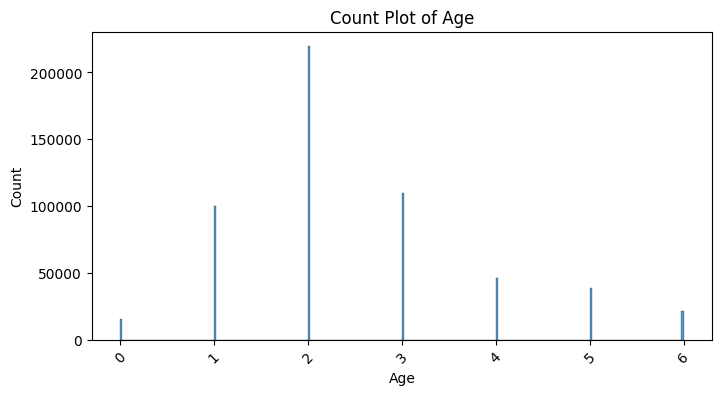

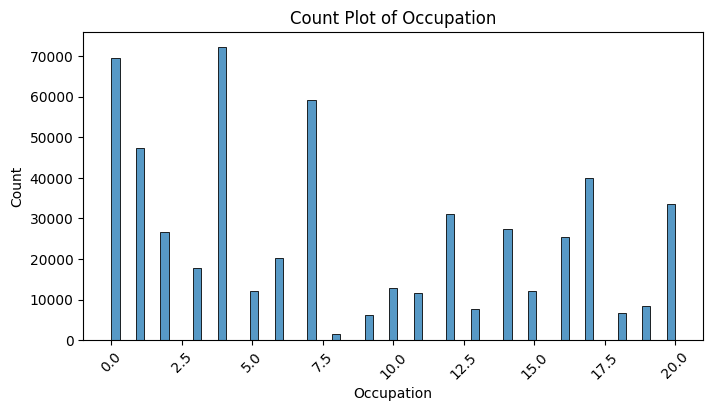

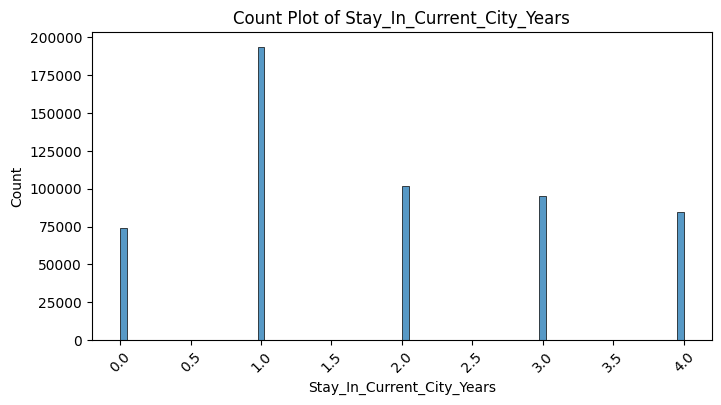

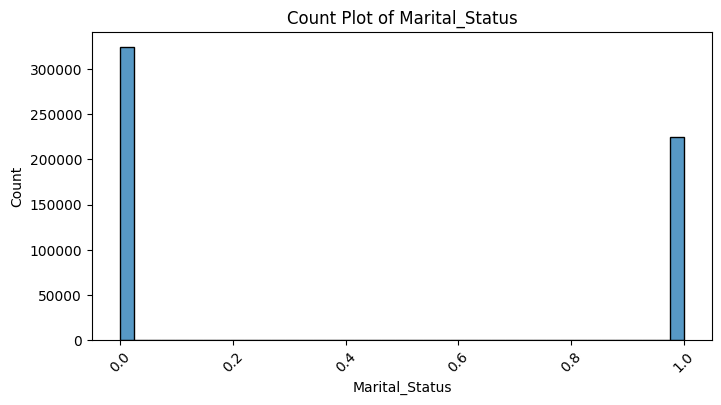

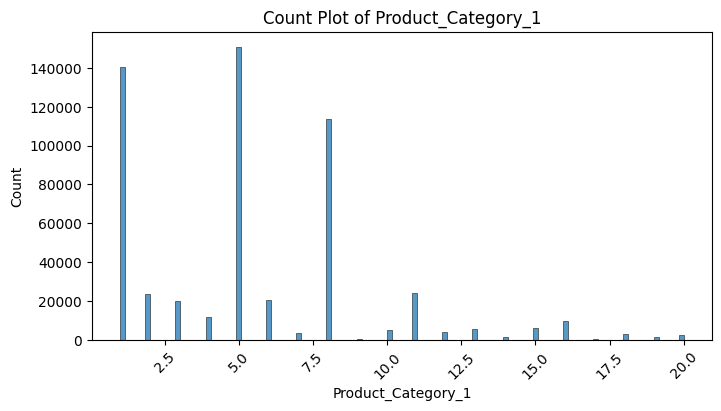

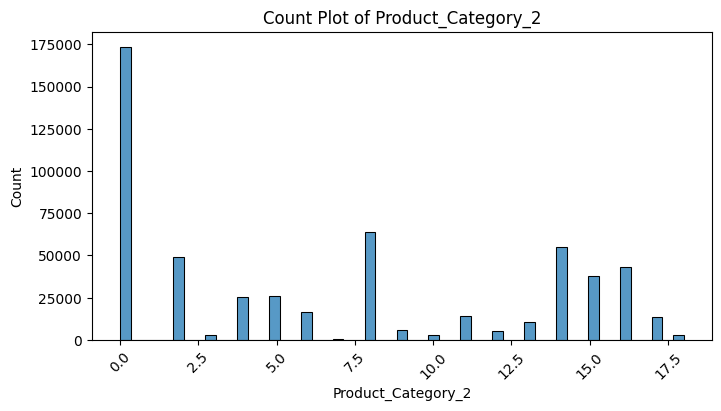

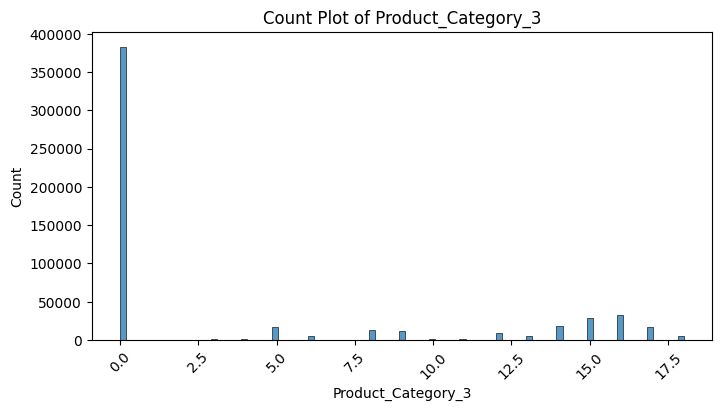

In [25]:
for col in num_col:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

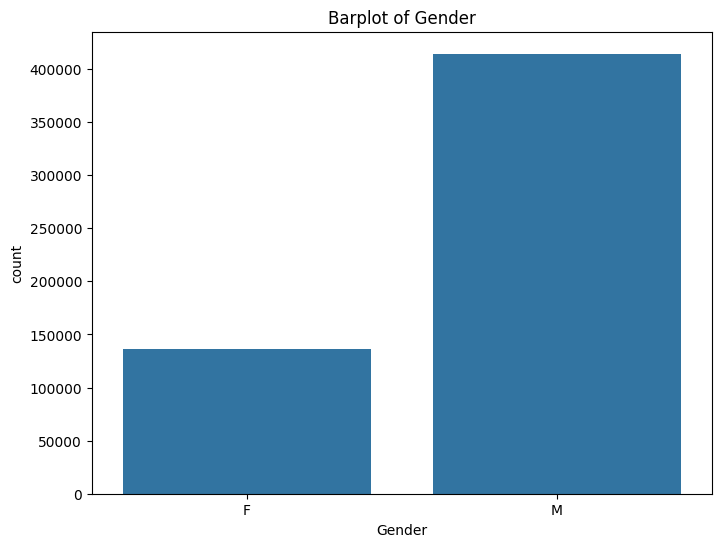

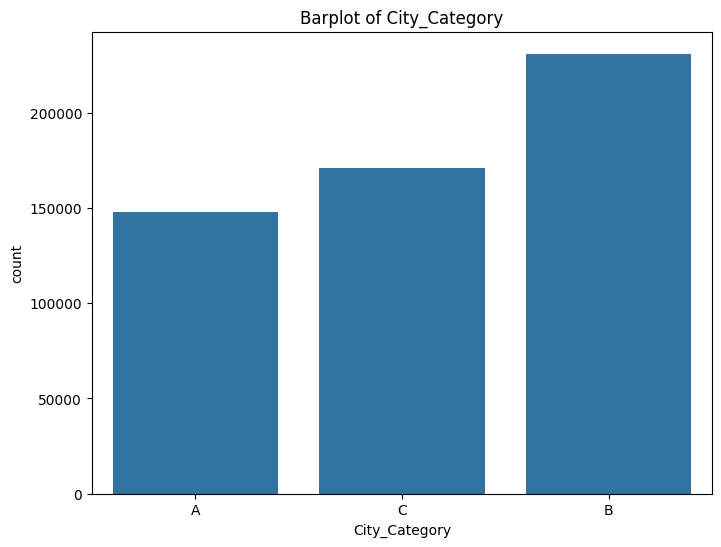

In [26]:
for col in cat_col:
    plt.figure(figsize=(8,6))
    sns.countplot(x=df[col] , data=df)
    plt.title(f"Barplot of {col}")
    plt.show()

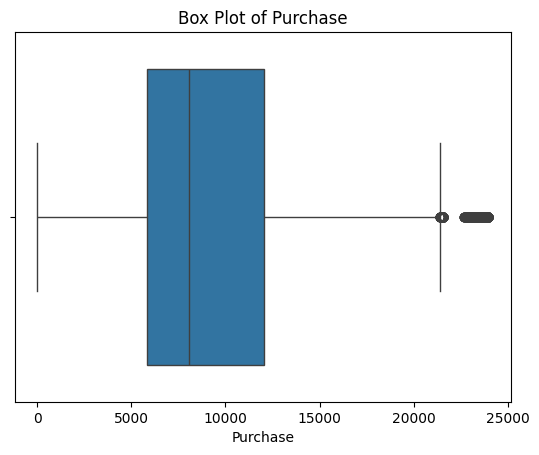

In [27]:
sns.boxplot(x=df["Purchase"])
plt.title("Box Plot of Purchase")
plt.show()

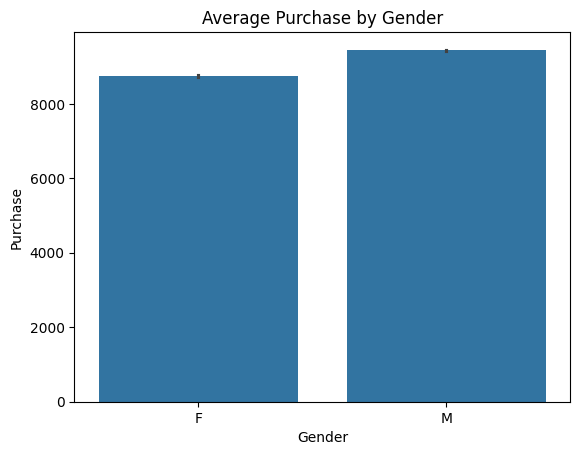

In [28]:
sns.barplot(data=df, x="Gender", y="Purchase")
plt.title("Average Purchase by Gender")
plt.show()

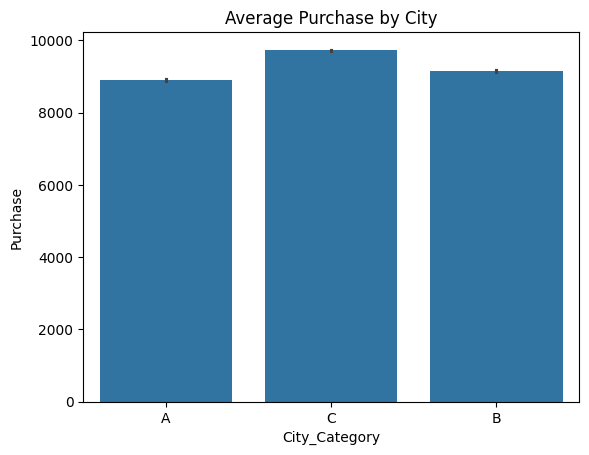

In [29]:
sns.barplot(data=df, x="City_Category", y="Purchase")
plt.title("Average Purchase by City")
plt.show()

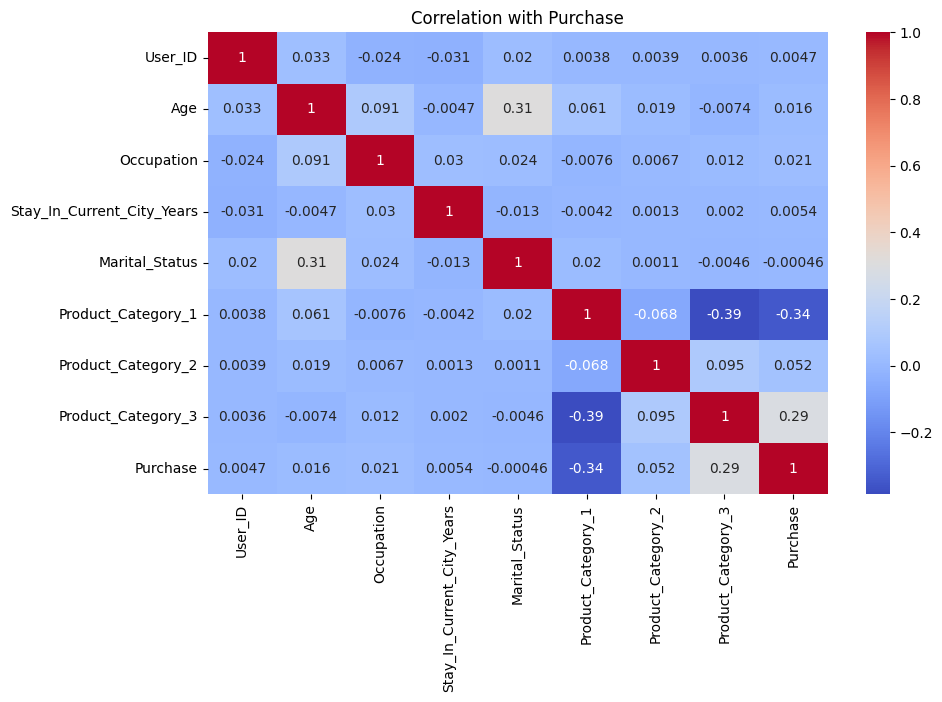

In [30]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation with Purchase")
plt.show()

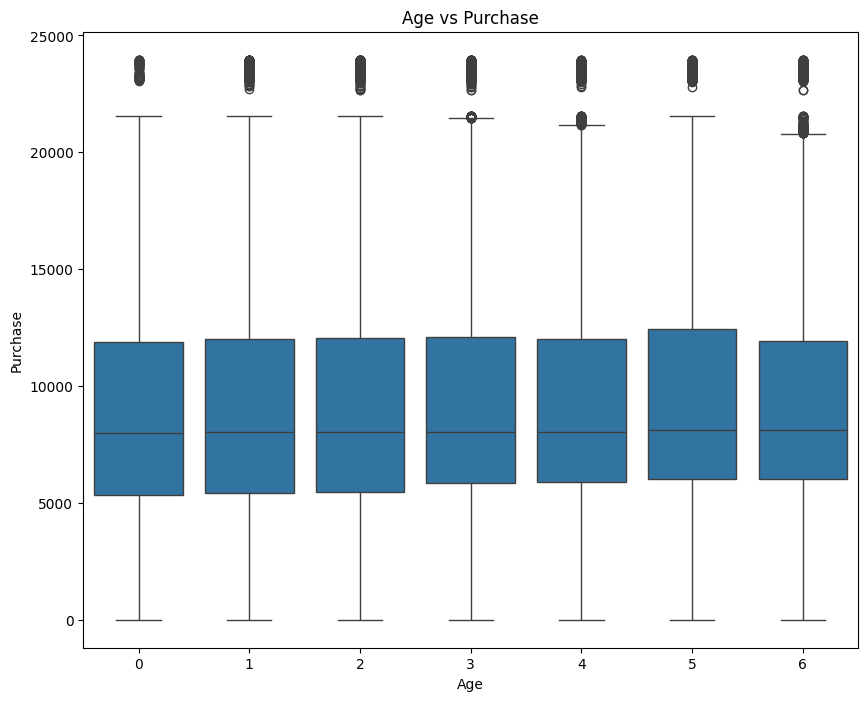

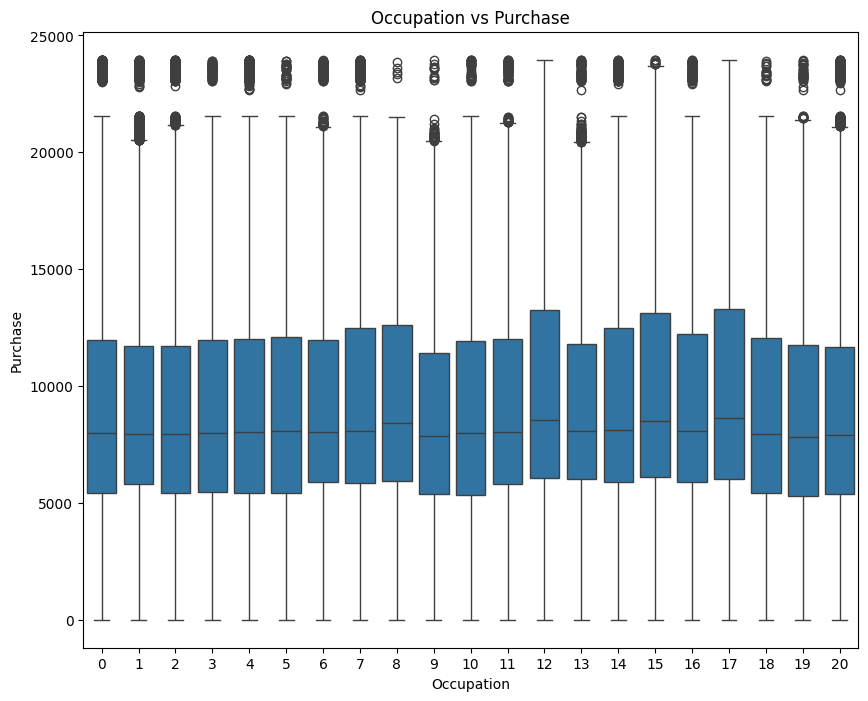

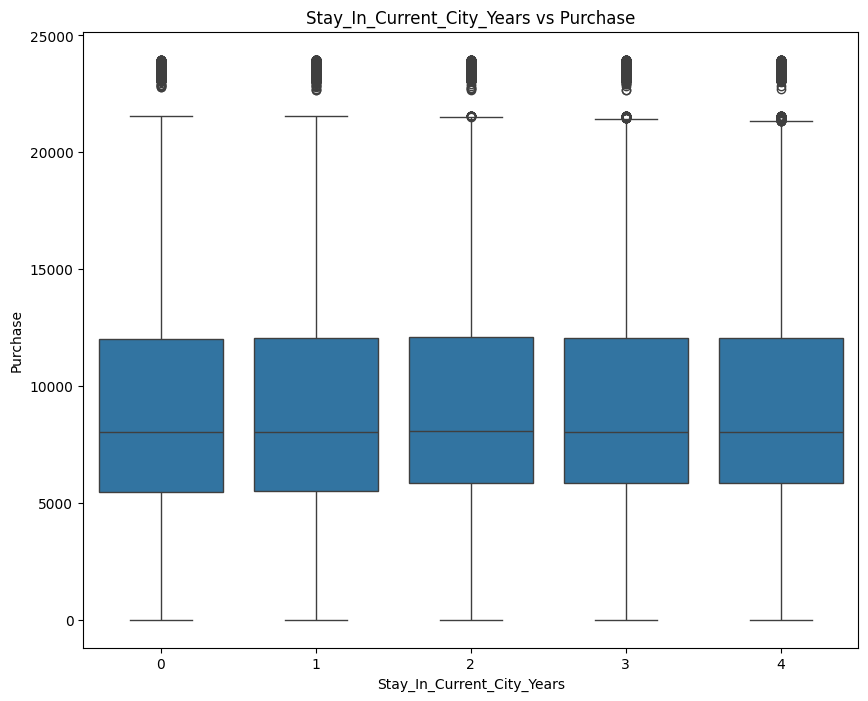

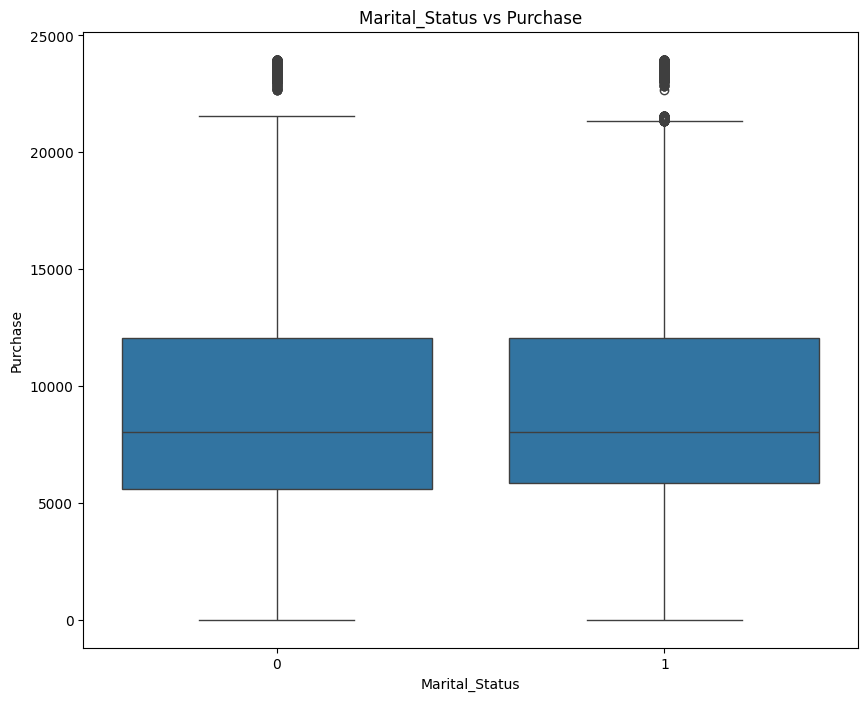

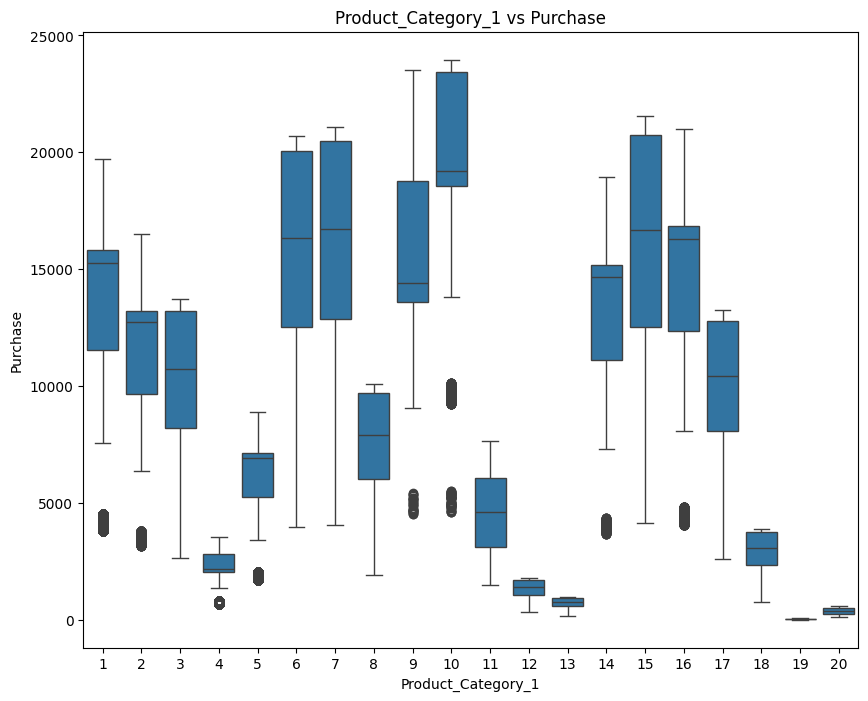

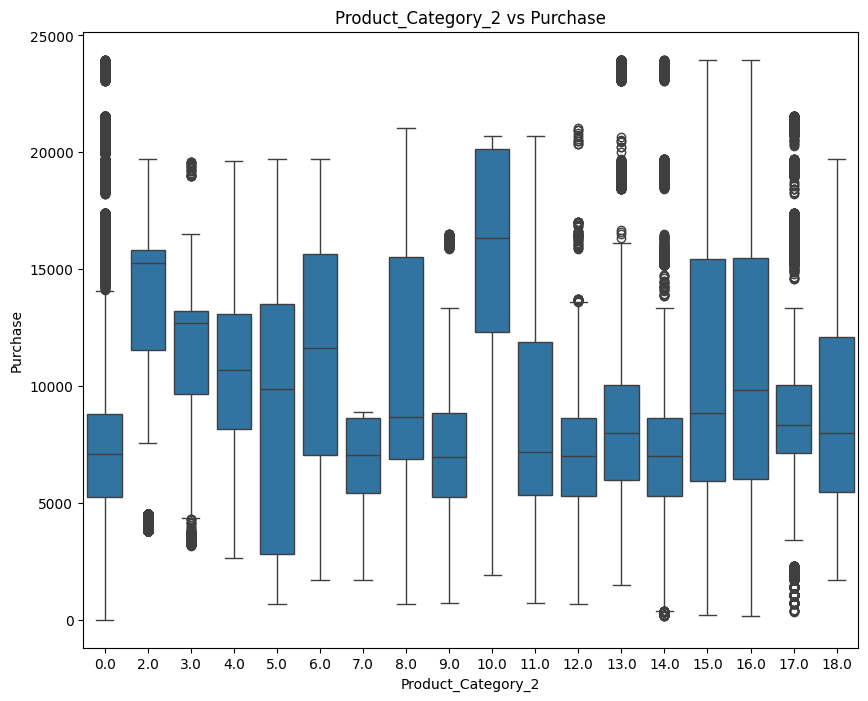

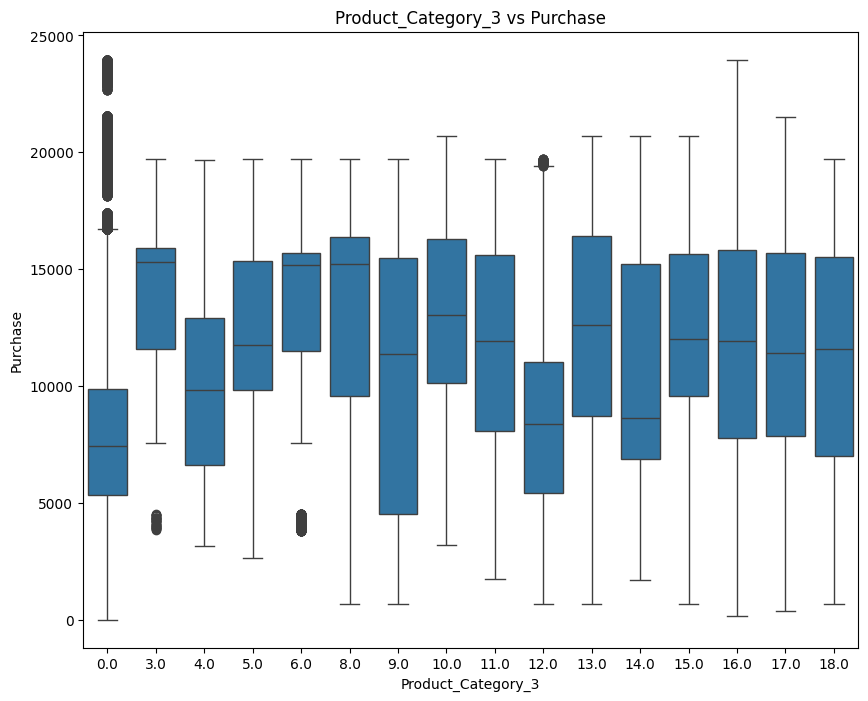

In [31]:
for col in num_col:
    plt.figure(figsize=(10,8))
    sns.boxplot(y='Purchase' ,x=col, data=df)
    plt.title(f"{col} vs Purchase")
    plt.show()

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase'],
      dtype='object')

In [34]:
df['Product_ID'].value_counts()

Product_ID
P00265242    1880
P00025442    1615
P00110742    1612
P00112142    1562
P00057642    1470
             ... 
P00314842       1
P00298842       1
P00231642       1
P00204442       1
P00066342       1
Name: count, Length: 3631, dtype: int64

In [42]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


product_id = df['Product_ID']

X = df.drop(columns=['Purchase', 'User_ID', 'Product_ID'])
y = df['Purchase']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


le_gender = LabelEncoder()
le_city = LabelEncoder()

X_train['Gender'] = le_gender.fit_transform(X_train['Gender'])
X_test['Gender'] = le_gender.transform(X_test['Gender'])

X_train['City_Category'] = le_city.fit_transform(X_train['City_Category'])
X_test['City_Category'] = le_city.transform(X_test['City_Category'])


freq = product_id[X_train.index].value_counts()
X_train['Product_ID_FE'] = product_id[X_train.index].map(freq)
X_test['Product_ID_FE'] = product_id[X_test.index].map(freq).fillna(0)

In [51]:
product_id.value_counts().head()

Product_ID
P00265242    1880
P00025442    1615
P00110742    1612
P00112142    1562
P00057642    1470
Name: count, dtype: int64

In [36]:
from xgboost import XGBRegressor

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))

MAE : 1957.6460871709135
MSE : 6933364.05096822
RMSE: 2633.128187340719
R²  : 0.7240581709529057


In [38]:
train_r2 = xgb.score(X_train, y_train)
test_r2 = xgb.score(X_test, y_test)

print("Train R2:", train_r2)
print("Test R2 :", test_r2)

Train R2: 0.7503797874863539
Test R2 : 0.7240581709529057
